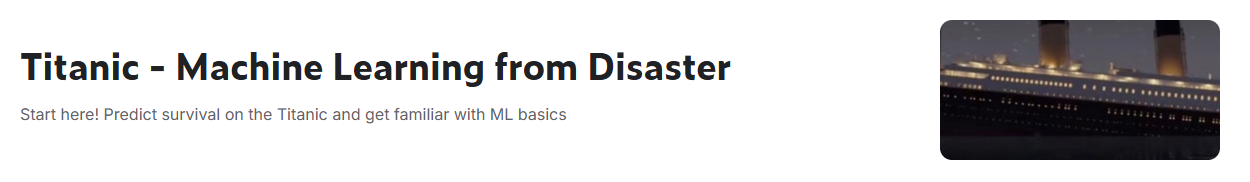

* https://www.kaggle.com/competitions/titanic/leaderboard

<pre>

datetime   - hourly date + timestamp  
season     - 1 = spring, 2 = summer, 3 = fall, 4 = winter 
holiday    - whether the day is considered a holiday
workingday - whether the day is neither a weekend nor holiday
weather    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
             2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
             3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
             4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
temp       - temperature in Celsius
atemp      - "feels like" temperature in Celsius
humidity   - relative humidity
windspeed  - wind speed
casual     - number of non-registered user rentals initiated
registered - number of registered user rentals initiated
count      - number of total rentals

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split     #문제/답 분리
from sklearn.linear_model import LinearRegression, Ridge, Lasso        #회귀모델 (선형모델) --- 음수값 처리 불가능
from sklearn.ensemble import RandomForestRegressor       #회귀모델 (트리모델) --- 음수값 처리 가능

from sklearn.metrics import root_mean_squared_log_error  #평가 매트릭스(rmse)
from sklearn.metrics import mean_squared_error           #평가 매트릭스(mse)

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler    #정규화(스케일링)
from sklearn.decomposition import PCA                    #차원 축소

#차트 관련 속성 (한글처리, 그리드)  폰트 설정 가능
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# **[1] Data Load**

In [3]:
train = pd.read_csv("../datas/bike/train.csv", parse_dates=['datetime'])  #parse_dates=['datetime'] : 글자로 되어있는 datetime을 애초에 날짜 형식으로 캐스팅(변환)
test = pd.read_csv("../datas/bike/test.csv", parse_dates=['datetime'])
sub = pd.read_csv("../datas/bike/sampleSubmission.csv")

In [4]:
train.shape, test.shape, sub.shape

((10886, 12), (6493, 9), (6493, 2))

In [5]:
train.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


In [6]:
test.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000


In [7]:
sub.head(2)

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[us]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(5)
memory usage: 456.7 KB


* <font color='red'> 결측 없음
* <font color='red'> 글자 있음 > datetime=str : 연월일시 숫자로 분리하면 datetime은 버려도 됨
* 문제지/답안지 나눠져있기 때문에 별도로 지정 안 해도 됨

## 'datetime' 연월일시 분리

In [10]:
train['yy'] = train['datetime'].dt.year
train['mm'] = train['datetime'].dt.month
train['dd'] = train['datetime'].dt.day
train['hh'] = train['datetime'].dt.hour
train['week'] = train['datetime'].dt.weekday   #월요일~일요일 : 순서대로 0~6

test['yy'] = test['datetime'].dt.year
test['mm'] = test['datetime'].dt.month
test['dd'] = test['datetime'].dt.day
test['hh'] = test['datetime'].dt.hour
test['week'] = test['datetime'].dt.weekday

In [11]:
train = train.set_index("datetime")
test = test.set_index("datetime")
#datetime 함부로 버리지 X, 인덱스로 넣어두기
#set_index : 인덱스로 넣기
#reset_index : 다시 빼기

In [12]:
train.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week
datetime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5


In [13]:
test.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week
datetime,,,,,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,3


In [14]:
# test = test.reset_index()            #-------------- 인덱스로 넣기
# test.head(2)
# test  = test.set_index("datetime")   #-------------- 인덱스를 빼기
# test.head(2)

# **[2] EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도 확인(왜도, 첨도, 정규분포)

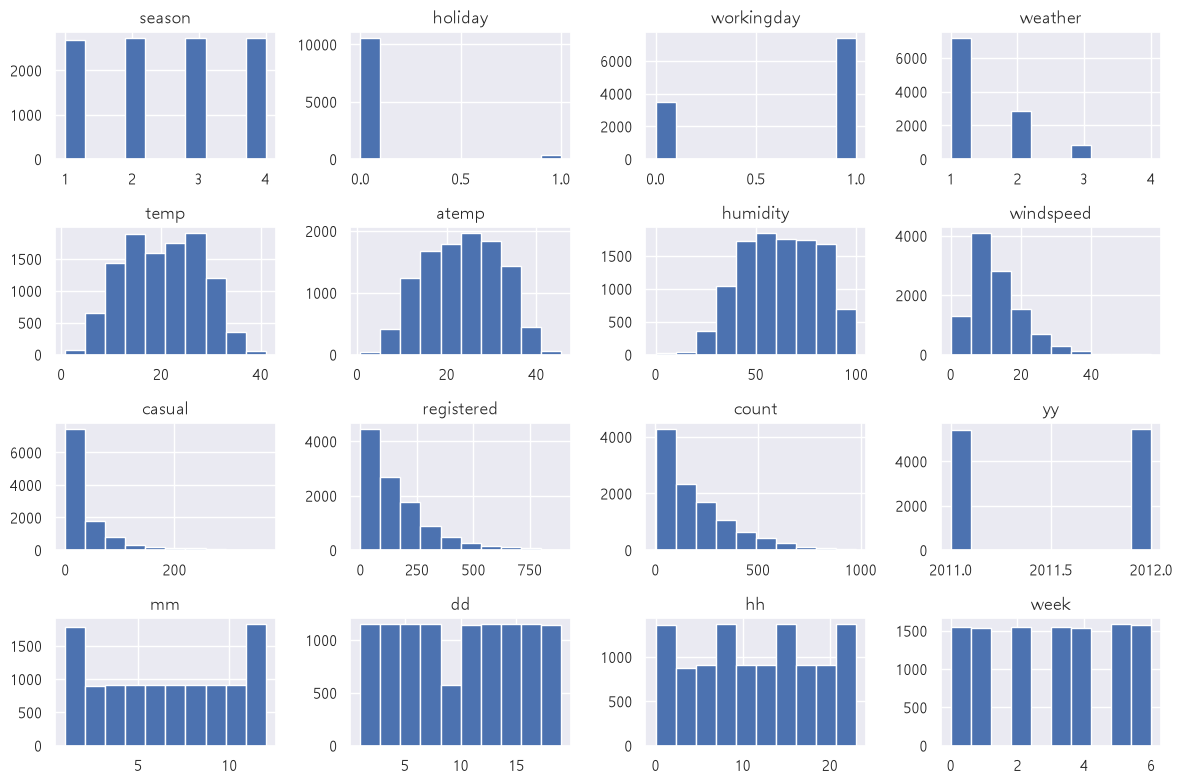

In [15]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

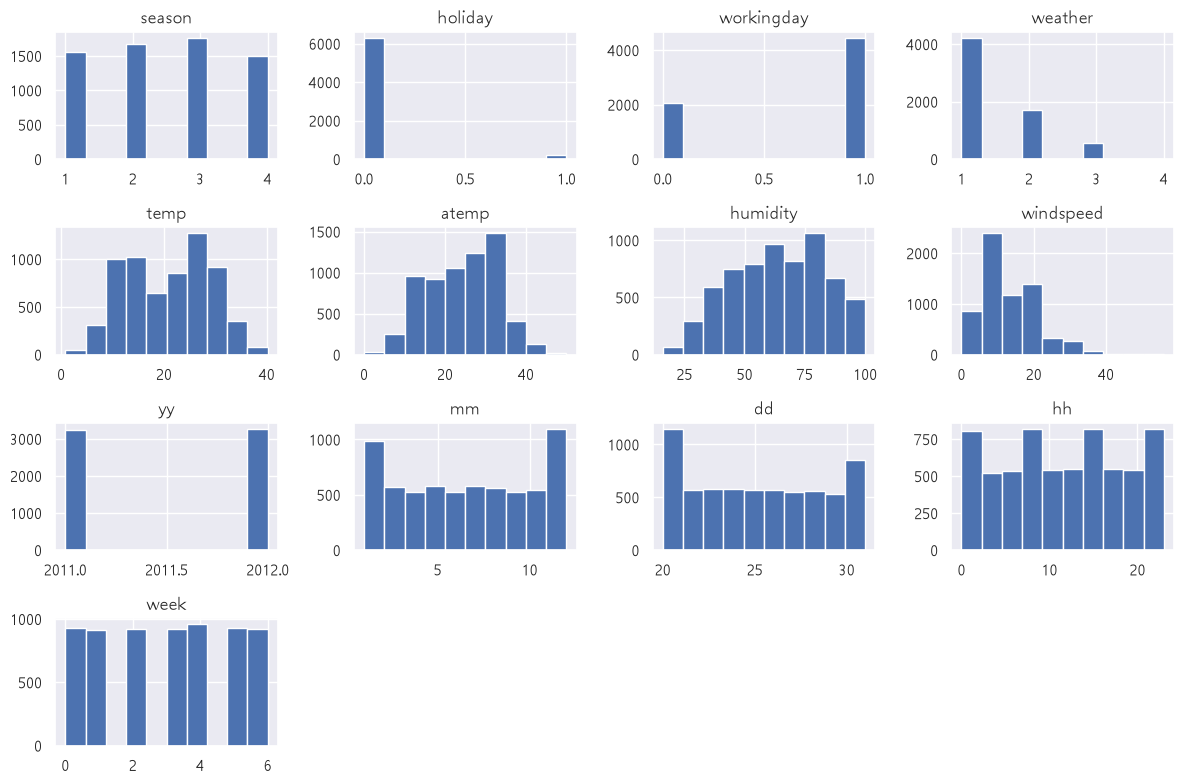

In [16]:
test.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

<font color=blue> **▼ 분석**
* train & test 비교했을 때
* casual과 registered가 왜 필요한지 확인 필요
* ['dd'] 컬럼 확인
  * train['dd'] = 1~20일
  * test['dd'] = 21~말일
   <font color=red>--> dd컬럼 비교가 불가능하기 때문에 삭제

## ['dd'] 컬럼 삭제

In [17]:
train = train.drop(columns=['dd'])
test = test.drop(columns=['dd'])

In [18]:
#train.head(2)
test.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,hh,week
datetime,,,,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,0,3
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,1,3


## 상관분석

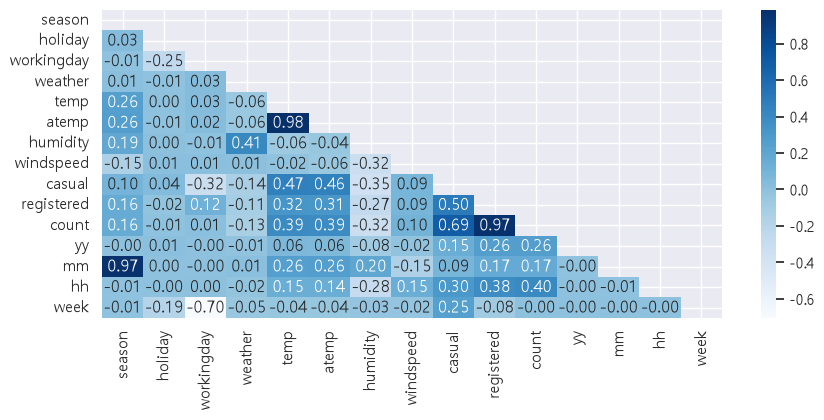

In [19]:
plt.figure(figsize=(10, 4))

# 반쪽으로 보기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()
# test에는 타겟피쳐가 없기 때문에 train만 봐도 됨

* atemp & temp : 0.98  --> 바이크 대여 수에 영향 큼
* count & registered : 0.97 (casual + registered = count 당연한 결과)
* workingday & week : -0.7
* mm & season : 0.97
* <font color="blue"> mm, week : 파생피쳐(연월일시 분리) 추가 생성으로 다중공선이 됨 : 필요시 파생피쳐는 삭제

<pre>

- 날짜 : 'yy', 'mm', 'hh', 'season'
- 날씨 : 'weather', 'temp', 'atemp', 'humidity', 'windspeed'
- 타겟 : 'casual', 'registered', 'count'
- 휴일 : 'holiday', 'workingday', 'week'

<font color="green"> <b> --> 날짜/날씨/휴일 분석 필요

### **날짜**
* 'yy', 'mm', 'hh', 'season'

#### 연/월/시간/계절별 대여수

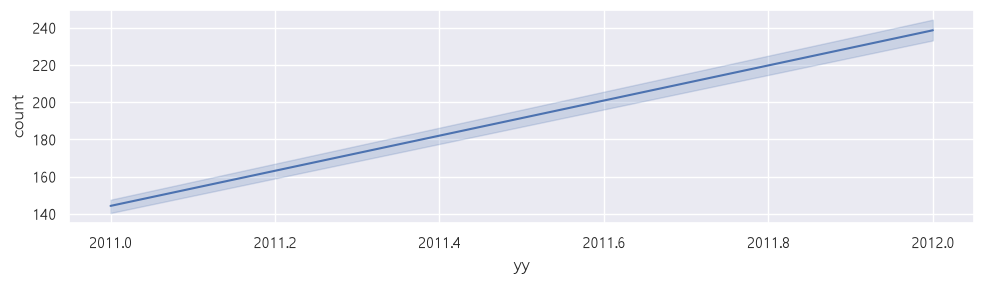

In [20]:
plt.figure(figsize=(10,3))
sns.lineplot(x="yy", y="count", data=train)
plt.tight_layout()
plt.show()

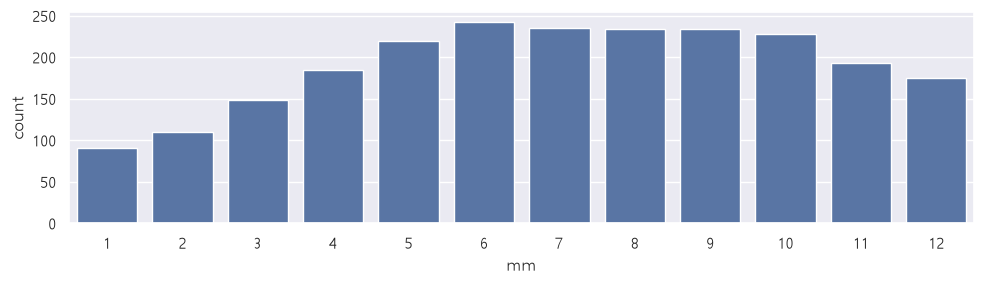

In [21]:
plt.figure(figsize=(10,3))
sns.barplot(x="mm", y="count", data=train, errorbar=None)
plt.tight_layout()
plt.show()

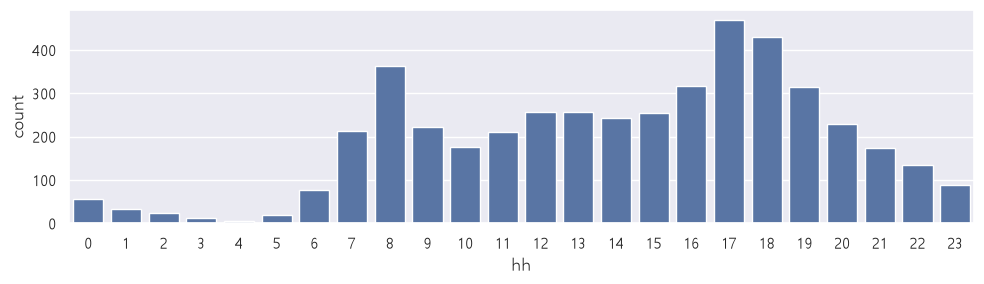

In [22]:
plt.figure(figsize=(10,3))
sns.barplot(x="hh", y="count", data=train, errorbar=None)
plt.tight_layout()
plt.show()

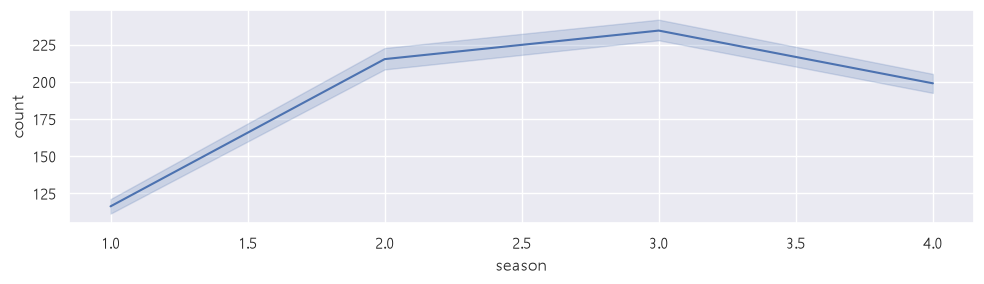

In [23]:
plt.figure(figsize=(10,3))
sns.lineplot(x="season", y="count", data=train)
plt.tight_layout()
plt.show()

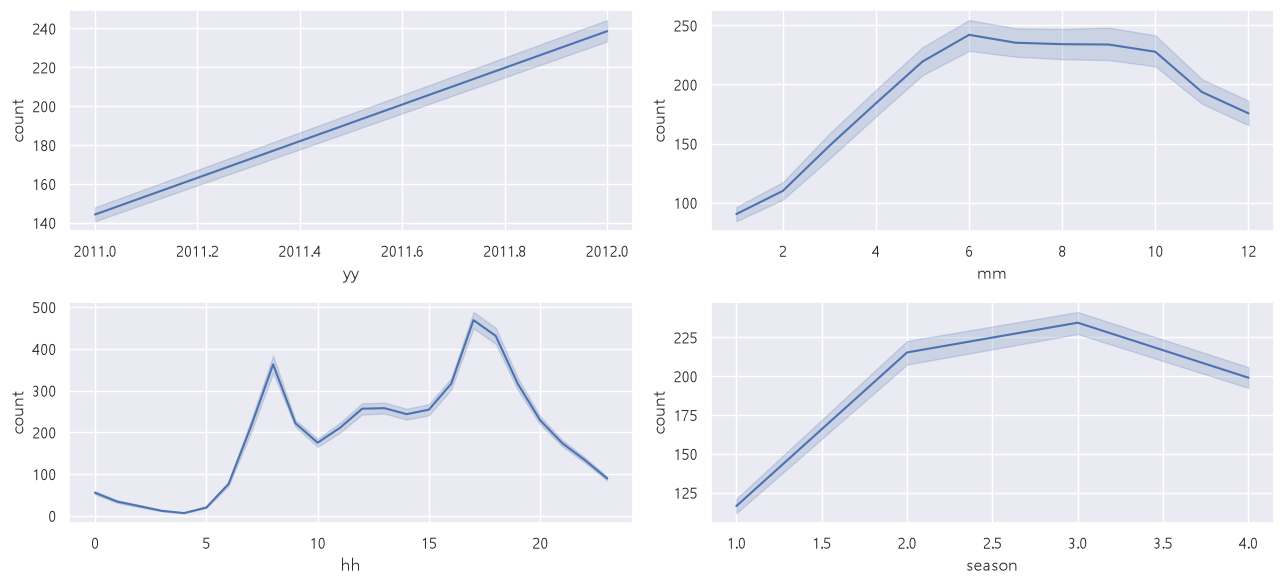

In [24]:
plt.figure(figsize=(13,6))


plt.subplot(2, 2, 1)
sns.lineplot(x="yy", y="count", data=train)

plt.subplot(2, 2, 2) 
sns.lineplot(x="mm", y="count", data=train)

plt.subplot(2, 2, 3) 
sns.lineplot(x="hh", y="count", data=train)

plt.subplot(2, 2, 4) 
sns.lineplot(x="season", y="count", data=train)


plt.tight_layout()
plt.show()

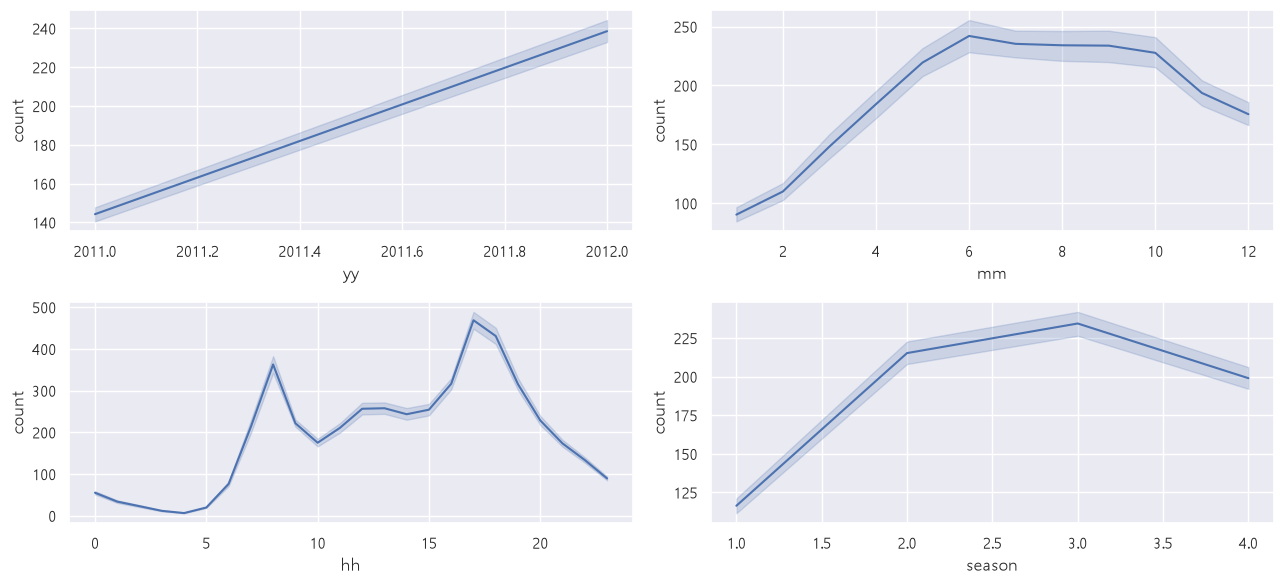

In [25]:
#반복문 사용!

fig, axes = plt.subplots(2,2, figsize=(13,6))
col_list=['yy', 'mm', 'hh', 'season']

for i, col in enumerate(col_list) :
    # 인덱스로 대입하니까 변수를 i로
    # 2*2에 0, 1이 루프돌며 차례대로 나와야 하니까 몫과 나머지로 인덱스 처리
    줄 = i//2   #몫 
    칸 = i%2    #나머지
    sns.lineplot(x=col, y="count", data=train, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

### **날씨**
* 'weather', 'temp', 'atemp', 'humidity', 'windspeed'

#### 날씨/온도/체감온도/습도/풍속 별 대여수

<font color=red> <b> 현장대여수(casual) : 온도만 봐도 예측 가능

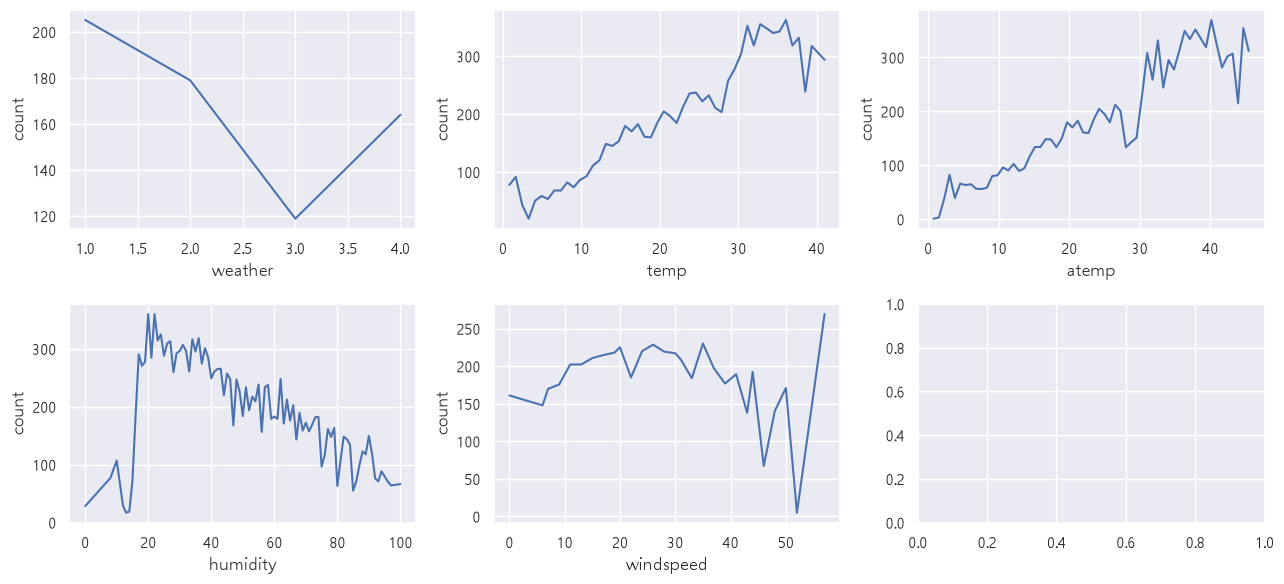

In [26]:
fig, axes = plt.subplots(2,3, figsize=(13,6))
col_list2=['weather', 'temp', 'atemp', 'humidity', 'windspeed']

for i, col2 in enumerate(col_list2) :
    # 인덱스로 대입하니까 변수를 i로
    # 2*3에 0, 1이 루프돌며 차례대로 나와야 하니까 몫과 나머지로 인덱스 처리
    줄 = i//3   #몫 
    칸 = i%3    #나머지
    sns.lineplot(x=col2, y="count", data=train, errorbar=None, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

#### **temp**

* 라인 : 평균온도
* 바 : 대여수

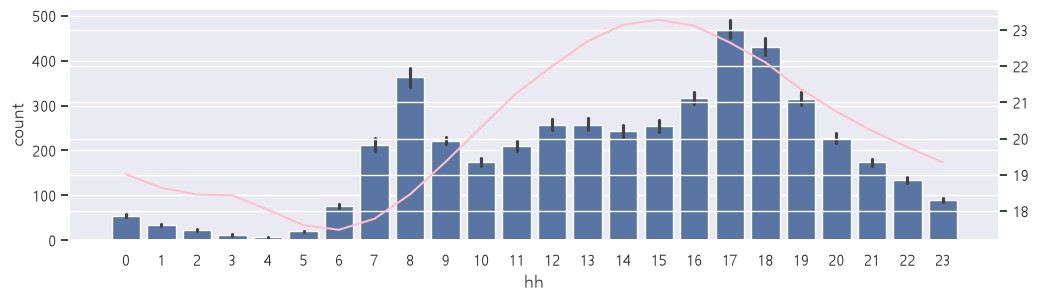

In [27]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="count", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean(), color='pink' )
plt.show()

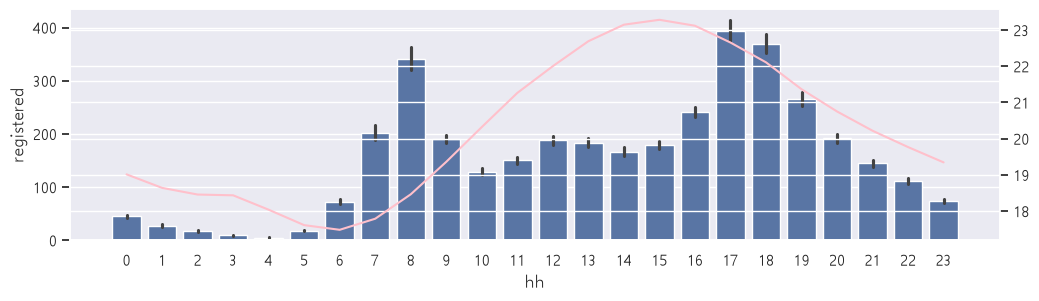

In [28]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="registered", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean(), color='pink' )
plt.show()

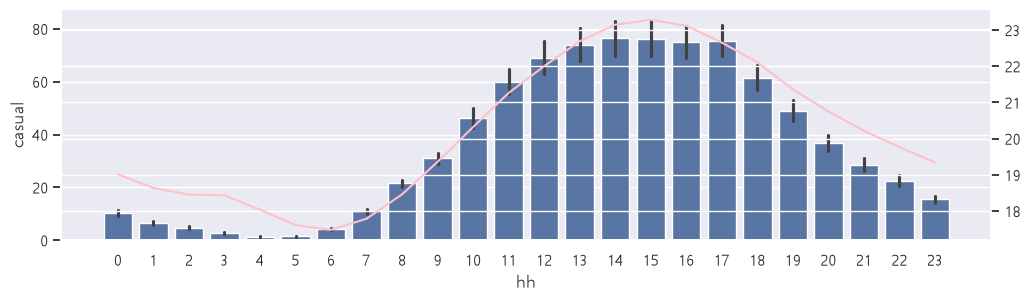

In [29]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="casual", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean(), color='pink' )
plt.show()

#### **humidity**

* 라인 : 평균습도
* 바 : 대여수

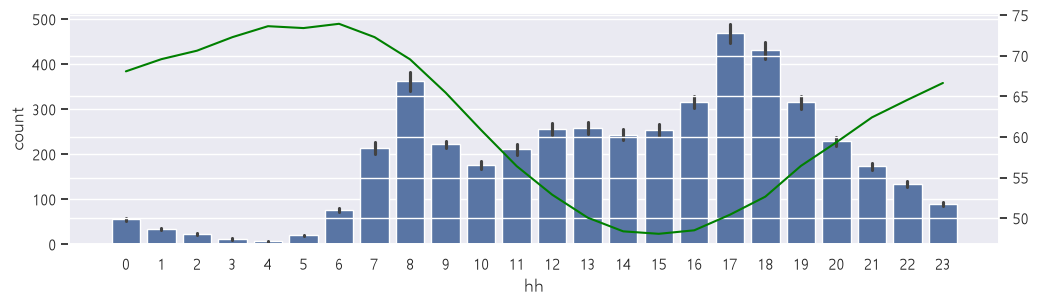

In [30]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="count", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean(), color='green' )
plt.show()

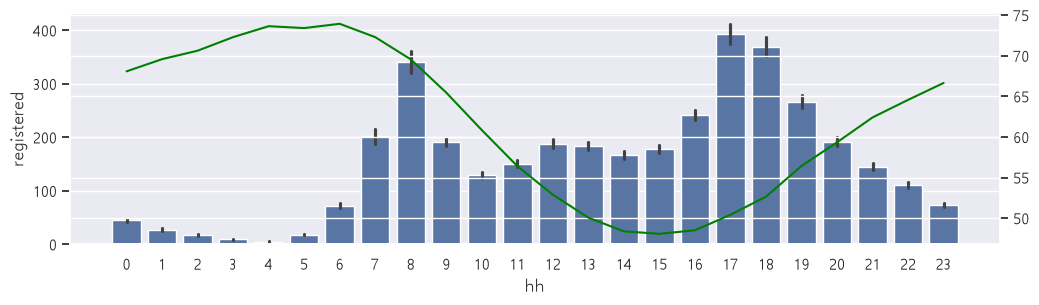

In [31]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="registered", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean(), color='green' )
plt.show()

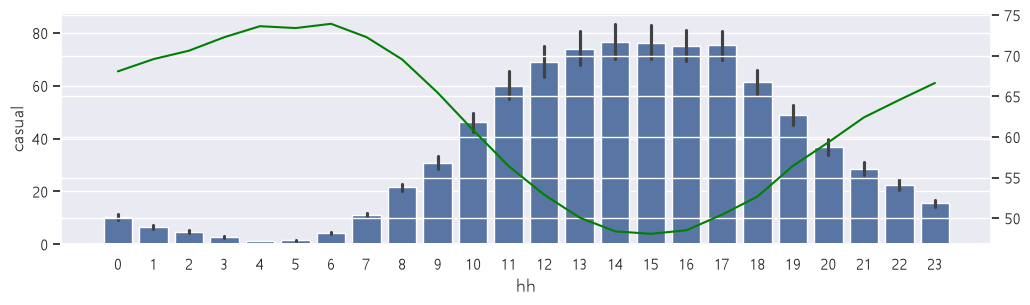

In [32]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="casual", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean(), color='green' )
plt.show()

#### **windspeed**

* 라인 : 풍속 평균
* 바 : 대여수

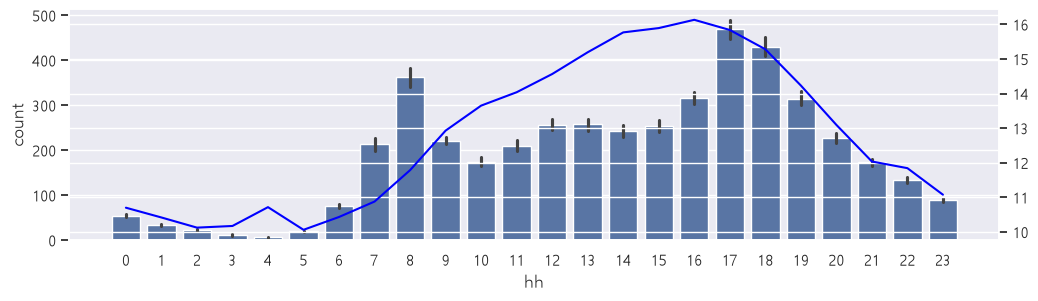

In [33]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="count", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean(), color='blue' )
plt.show()

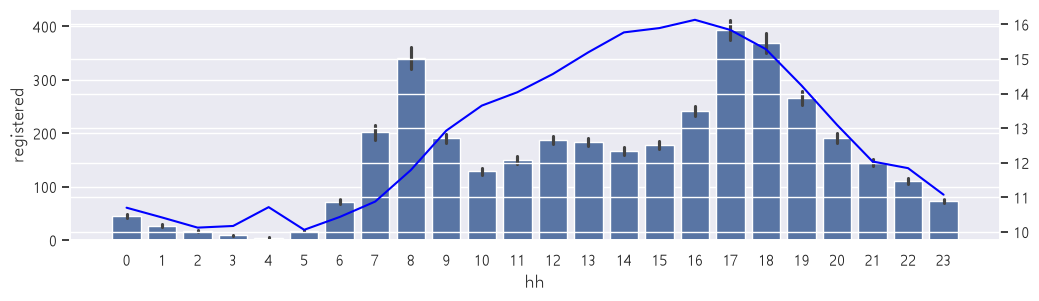

In [34]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="registered", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean(), color='blue' )
plt.show()

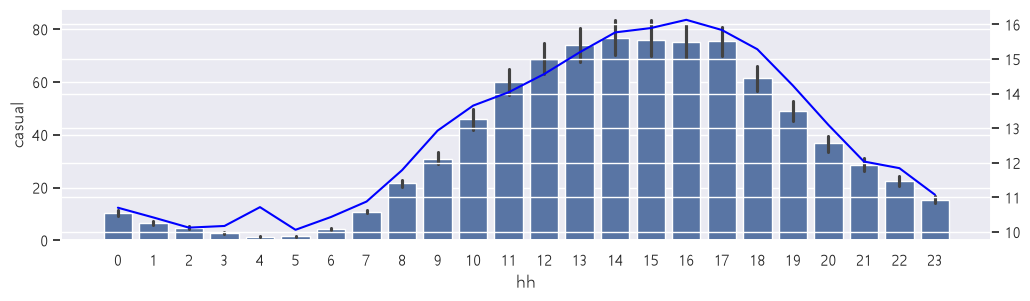

In [35]:
fig, axes = plt.subplots(figsize=(12,3))
sns.barplot(data=train, x="hh", y="casual", ax=axes)
axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean(), color='blue' )
plt.show()

#### **weather**

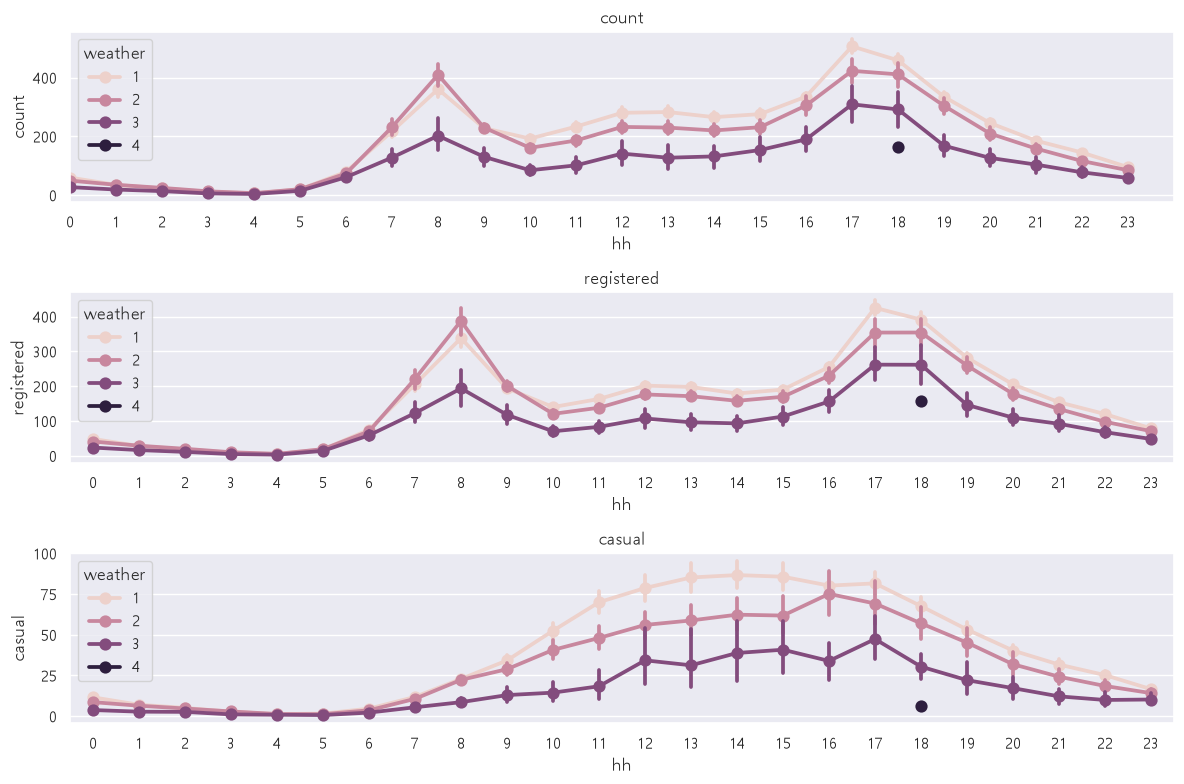

In [36]:
fig,ax = plt.subplots(nrows=3,ncols=1, figsize=(12,8))

sns.pointplot(data=train, x='hh', y='count', hue='weather', ax=ax[0])
ax[0].set(xlim=(0, 24))
ax[0].set(title="count")

sns.pointplot(data=train, x='hh', y='registered', hue='weather', ax=ax[1])
ax[1].set(title="registered")

sns.pointplot(data=train, x='hh', y='casual', hue='weather', ax=ax[2])
ax[2].set(title="casual")

plt.tight_layout()
plt.show()

### 타겟
* 'count'(총합), 'registered'(예약), 'casual'(현장)

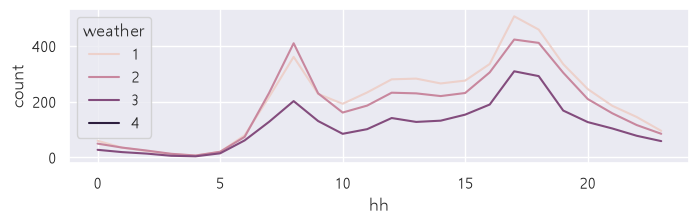

In [37]:
#계절(weather 그룹화_hue)별 시간대별 바이크대여

plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="count", hue="weather", data=train, errorbar=None)
plt.show()

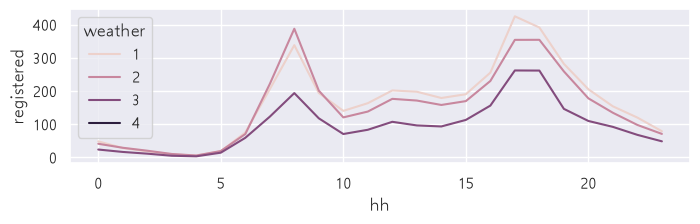

In [38]:
#계절(weather 그룹화_hue)별 시간대별 예약대여수

plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="registered", hue="weather", data=train, errorbar=None)
plt.show()

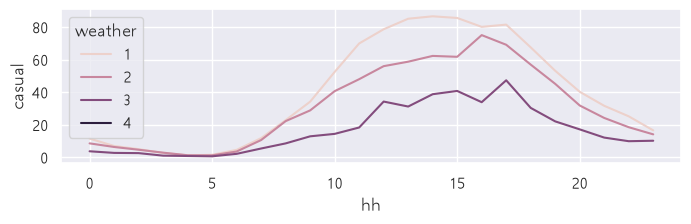

In [39]:
#계절(weather 그룹화_hue)별 시간대별 현장대여수

plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="casual", hue="weather", data=train, errorbar=None)
plt.show()

#### weather 4가 안 찍히는 이유!
  * 만몇개 중에 한줄밖에 없어서... 현장대여... 한겨울에... 월요일에... 습도가 86...

In [40]:
train[ train['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week
datetime,,,,,,,,,,,,,,,
2012-01-09 18:00:00,1,0,1,4,8.2,11.365,86,6.0032,6,158,164,2012,1,18,0


* 이새끼는 풍속이 22인데...
* 새벽 한시에는 왜 빌린걸까

In [41]:
test[ test['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,hh,week
datetime,,,,,,,,,,,,
2011-01-26 16:00:00,1,0,1,4,9.02,9.85,93,22.0028,2011,1,16,2
2012-01-21 01:00:00,1,0,0,4,5.74,6.82,86,12.9980,2012,1,1,5


### **평일/휴일**
* 'holiday', 'workingday', 'week'

#### 공휴일/워킹데이(평일/주말) 대여수

In [42]:
train[['holiday','workingday']].value_counts()

#행 순서대로
#평일(까만날) - 7412
#주말(쉬는날) - 3163
#공휴일       - 311
#개복잡하니까 이럴 때 파생피쳐 만들어야 함

holiday  workingday
0        1             7412
         0             3163
1        0              311
Name: count, dtype: int64

#### **데이터 수정**

In [43]:
train['day_type'] = 0

#holiday==0  workingday==1  : 그냥 까만 평일
train.loc [ (train['holiday']==0) & (train['workingday']==1), 'day_type' ] = 0

#holiday==0  workingday==0  : 공휴일도 평일도 아닌 주말
train.loc [ (train['holiday']==0) & (train['workingday']==0), 'day_type' ] = 1

#holiday==1  workingday==0  : 공휴일
train.loc [ (train['holiday']==1) & (train['workingday']==0), 'day_type' ] = 2

train['day_type'].value_counts()

day_type
0    7412
1    3163
2     311
Name: count, dtype: int64

In [44]:
test['day_type'] = 0

#holiday==0  workingday==1  : 그냥 까만 평일
test.loc [ (test['holiday']==0) & (test['workingday']==1), 'day_type' ] = 0

#holiday==0  workingday==0  : 공휴일도 평일도 아닌 주말
test.loc [ (test['holiday']==0) & (test['workingday']==0), 'day_type' ] = 1

#holiday==1  workingday==0  : 공휴일
test.loc [ (test['holiday']==1) & (test['workingday']==0), 'day_type' ] = 2

test['day_type'].value_counts()

day_type
0    4453
1    1851
2     189
Name: count, dtype: int64

#### **day_type별 count 평균**

In [45]:
train[ train['day_type']==0 ].groupby('hh')['count'].mean()

hh
0      36.732258
1      16.003236
2       8.436066
3       4.892734
4       5.363636
5      24.529032
6     102.577419
7     290.690323
8     479.945161
9     242.293548
10    133.596774
11    157.019355
12    199.347267
13    197.160772
14    180.366559
15    198.627010
16    292.466238
17    529.209003
18    495.485531
19    349.282958
20    249.363344
21    184.855305
22    138.344051
23     88.996785
Name: count, dtype: float64

#### **day_type별 현황 시각화**

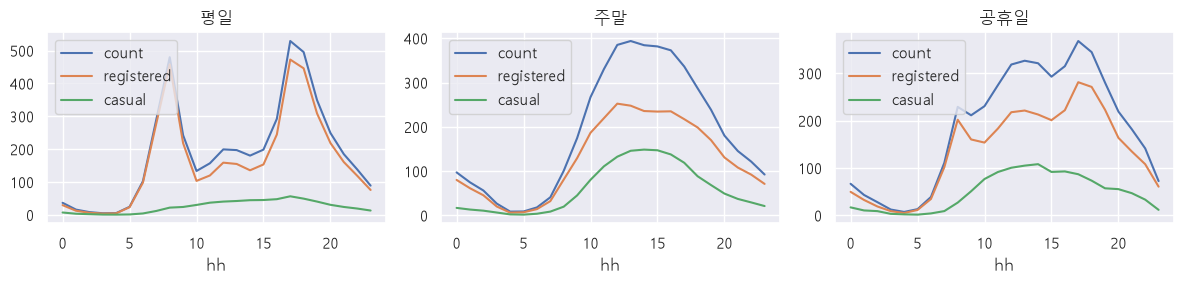

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3)) 

g0 = train[ train['day_type']==0 ].groupby('hh')[['count', 'registered', 'casual']].mean() 
g0.plot(ax=ax1, title='평일')

g1 = train[ train['day_type']==1 ].groupby('hh')[['count', 'registered', 'casual']].mean() 
g1.plot(ax=ax2, title='주말')

g2 = train[ train['day_type']==2 ].groupby('hh')[['count', 'registered', 'casual']].mean()
g2.plot(ax=ax3, title='공휴일')

plt.tight_layout()
plt.show()

### **요일(파생피쳐)별 대여수**
* 'week'

#### **요일/휴일 별 대여(예약/현장/총합) 현황 시각화**

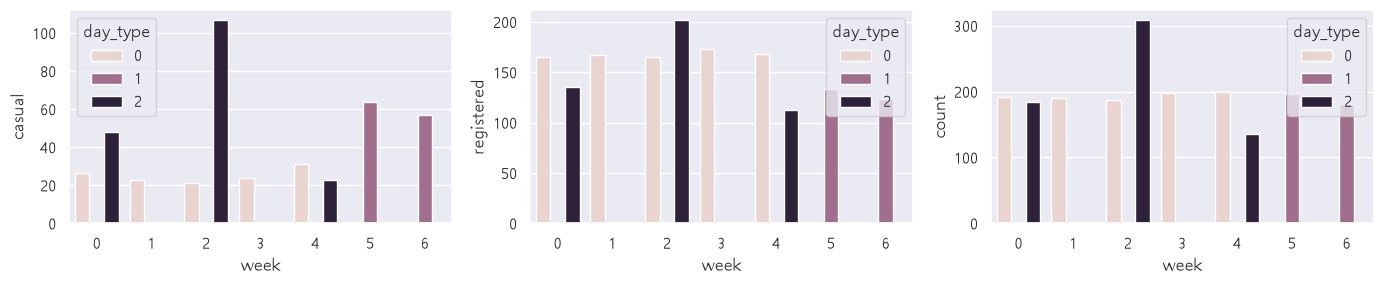

In [47]:
fig, axes = plt.subplots(1,3, figsize=(14,3))
col_list3=['casual', 'registered', 'count']

for i, col3 in enumerate(col_list3) :
    줄 = i//3   #몫 
    칸 = i%3    #나머지
    sns.barplot(x="week", y=col3, data=train, hue="day_type", errorbar=None, ax=axes[i])

plt.tight_layout()
plt.show()

<font color=blue> **▼ 분석**
* daytype 2 : 평일 중에 week 2 수요일이 너무 큼
     * 이유 확인 필요 : 매년 7월, 미국 독립기념일 불꽃놀이 대규모 축제
     * 아웃라이어 아님
* 2012년 10월 말 : 허리케인 샌디
     * 아웃라이어

### **월(파생피쳐)별 대여수**
* 'mm'

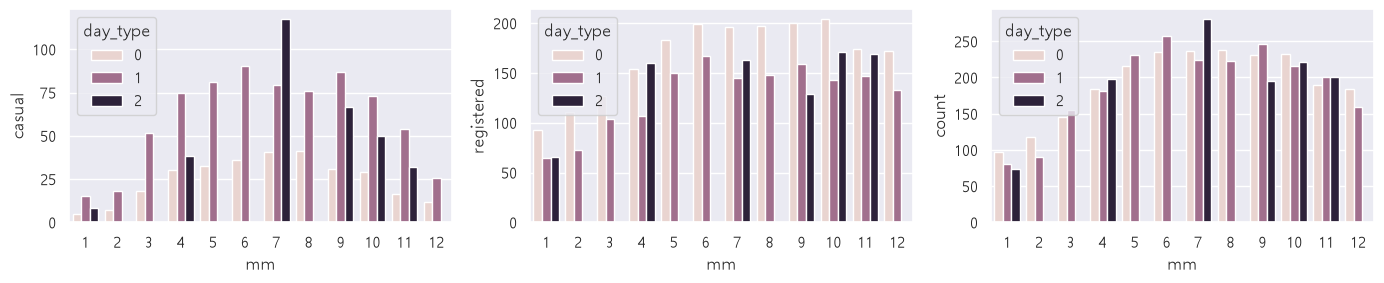

In [48]:
fig, axes = plt.subplots(1,3, figsize=(14,3))
col_list3=['casual', 'registered', 'count']

for i, col3 in enumerate(col_list3) :
    줄 = i//3   #몫 
    칸 = i%3    #나머지
    sns.barplot(x="mm", y=col3, data=train, hue="day_type", errorbar=None, ax=axes[i])

plt.tight_layout()
plt.show()

## 이상치(outlier)

* 박스플롯은 이상치 확인뿐만 아니라 중앙값으로 영향정도도 확인 가능

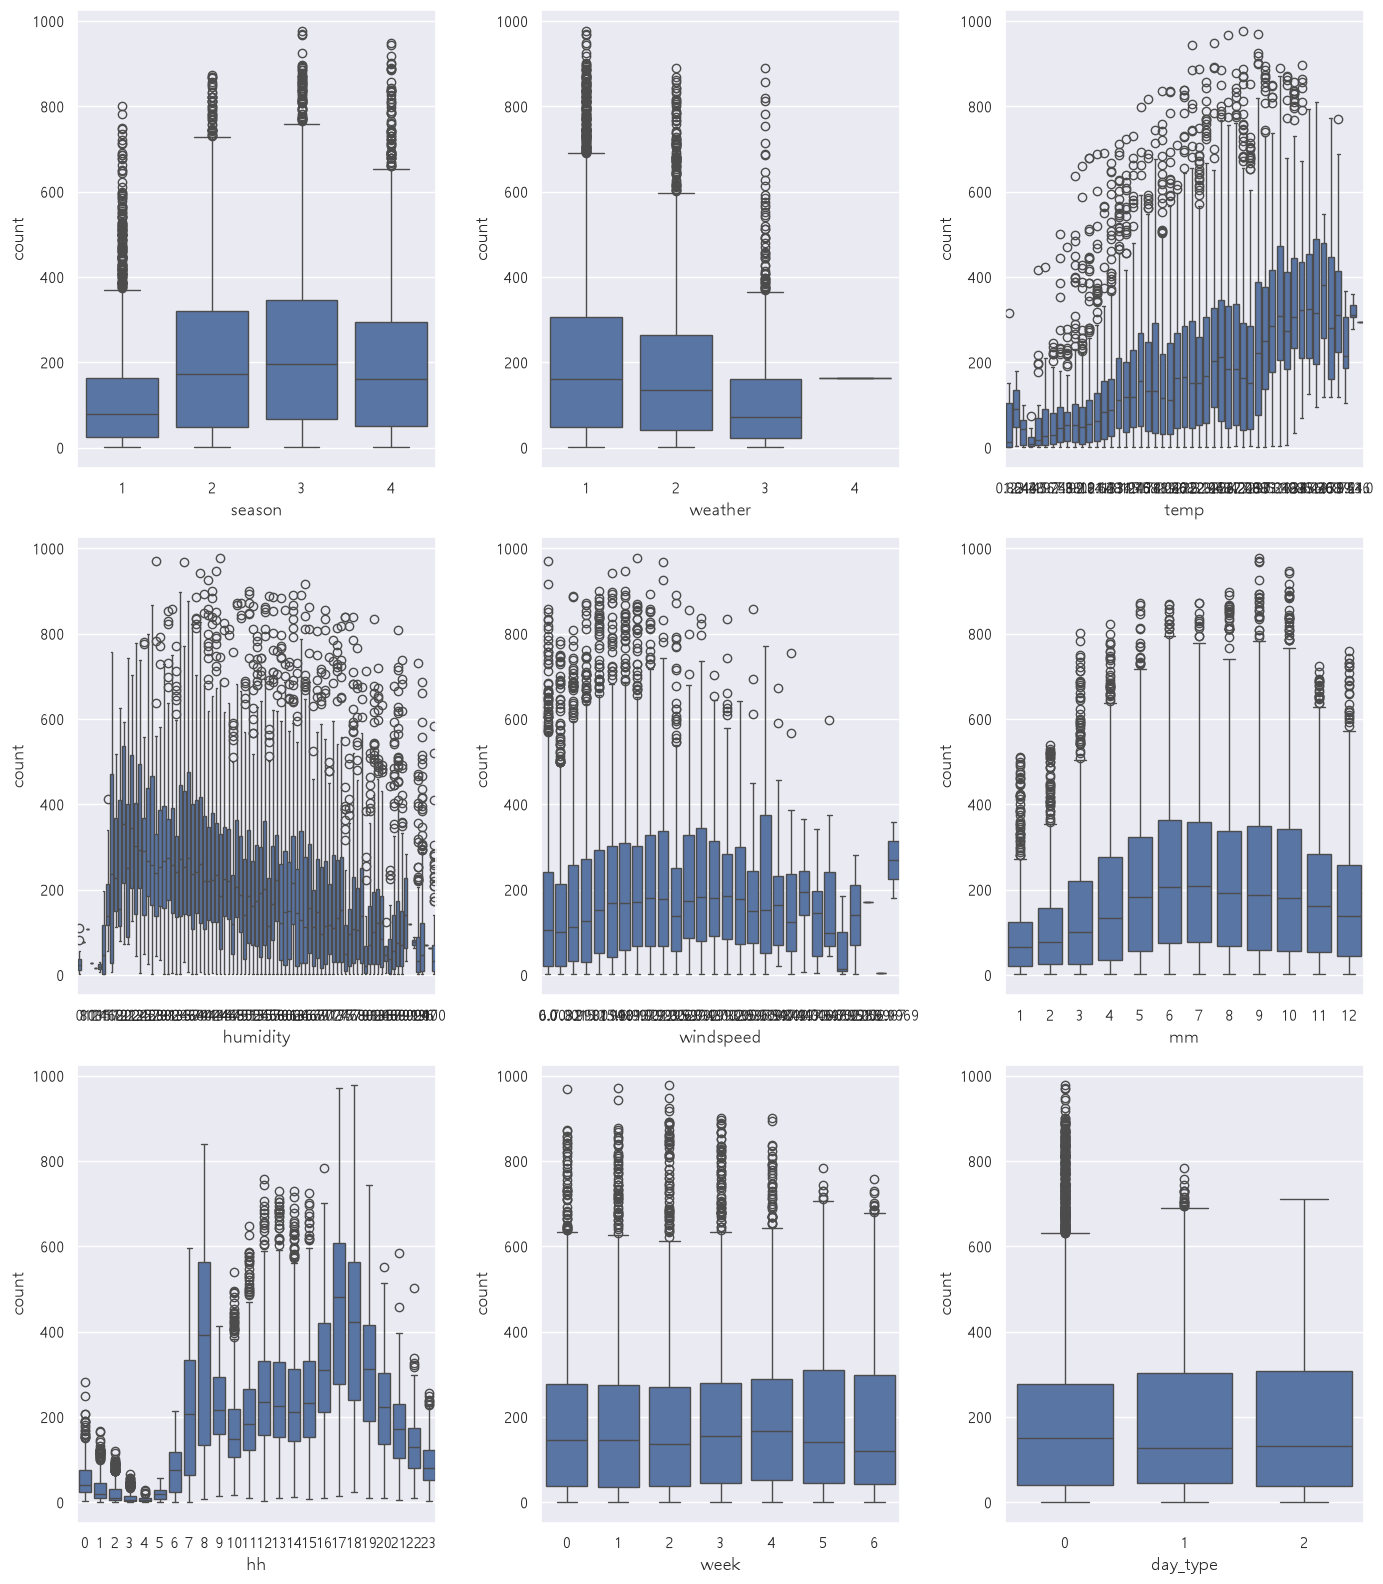

In [49]:
fig, axes = plt.subplots(3,3, figsize=(14,16))
col_list = ['season', 'weather', 'temp', 'humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']

for i, col in enumerate(col_list) :
    줄 = i//3 
    칸 = i%3 
    sns.boxplot(x=col, y="count", data=train, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

In [50]:
train['windspeed'].value_counts()
#풍속이 0??? >> 이상치

windspeed
0.0000     1313
8.9981     1120
11.0014    1057
12.9980    1042
7.0015     1034
15.0013     961
6.0032      872
16.9979     824
19.0012     676
19.9995     492
22.0028     372
23.9994     274
26.0027     235
27.9993     187
30.0026     111
31.0009      89
32.9975      80
35.0008      58
39.0007      27
36.9974      22
43.0006      12
40.9973      11
43.9989       8
46.0022       3
56.9969       2
47.9988       2
51.9987       1
50.0021       1
Name: count, dtype: int64

### 풍속 0 : 이상치
* 0.0000 : 1313건

In [51]:
train[train['windspeed']==0]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week,day_type
datetime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,0,5,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,5,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,2,5,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,3,5,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-17 12:00:00,4,0,1,2,16.40,20.455,87,0.0,21,211,232,2012,12,12,0,0
2012-12-17 15:00:00,4,0,1,2,17.22,21.210,88,0.0,15,196,211,2012,12,15,0,0
2012-12-18 08:00:00,4,0,1,1,15.58,19.695,94,0.0,10,652,662,2012,12,8,1,0


# **[3] 공통함수**

### RMSLE
* <font color=red> <b> 정확도가 중요한 데이터에 사용 </font> </b>
  * ex) 실제 10 > 예측 20 : 2배   /  실제 1000 > 예측 1010 : 1.01배  ==> MSLE에서는 첫번째 오차를 훨씬 심각하게 봄 <br>
* MSE: 실제값과 예측값의 차이를 그대로 제곱해 평가하는 지표
* RMSLE: 실제값과 예측값에 로그를 적용해 비율 차이를 중심으로 평가하는 지표

$RMSLE=\sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }$ <br>
* mse에 log를 적용하는 이유 : 너무 큰 데이터의 영향을 줄이고, 큰 값과 작은 값의 차이를 상대적으로 다루기 위해서 <br>
* +1을 하는 이유 : 값이 0일 때도 log를 계산할 수 있도록

``` python
sklearn.metrics.root_mean_squared_log_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

▼ train/test 데이터 비율로 나눠진 경우
* 모델 지정 안 하면 기본 랜덤포레스트, 그게 아니면 모델 이름도 같이 출력

In [52]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)
    
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)

    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )

▼ train 데이터 통으로 넣을 경우
* 모델 지정 안 하면 기본 랜덤포레스트, 그게 아니면 모델 이름도 같이 출력
* 타겟 지정 안 하면 기본 count, 지정(입력)하면 그걸로

In [53]:
def myscore222(df, model=None, MY_TARGET="count") :
    X = df.drop(columns=['count','registered','casual'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, shuffle=False)
    
    if model is None : 
            model = RandomForestRegressor(
                n_estimators=100,
                random_state=1234
            )
    print(model.__class__.__name__) 
    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)
    
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)
    
    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )

    return model

In [54]:
rf = myscore222(train)

RandomForestRegressor
rmsle : 0.3440


## <font color=blue> **→1차 점수 : 우선 점수만**
* 0.47781 : 1207등

In [55]:
pred = rf.predict(test)
pred[:10]

array([ 13.21,   5.74,   4.65,   3.43,   2.88,   5.85,  35.51,  95.36,
       208.84, 125.48])

In [56]:
sub['count'] = pred
sub.head()

,datetime,count
0,2011-01-20 00:00:00,13.21
1,2011-01-20 01:00:00,5.74
2,2011-01-20 02:00:00,4.65
3,2011-01-20 03:00:00,3.43
4,2011-01-20 04:00:00,2.88


In [57]:
sub.to_csv("lec11_v01.csv", index=False)
#파일로 만들기

# **[4] 전처리&가공**

## (1) 이상치 처리 : windspeed가 0인 데이터 수정

* **[1] train_target = train에 target만 꺼내놓기**
* **[1] train + test = tt 생성**

In [58]:
print(train.shape, test.shape)

train_target = train[['count','registered','casual']]
#나중에 다시 합쳐야 하니 target으로 꺼내두기

tt = pd.concat([train, test],axis=0)
print(tt.shape)
tt.head()

(10886, 16) (6493, 13)
(17379, 16)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week,day_type
datetime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3.0,13.0,16.0,2011,1,0,5,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8.0,32.0,40.0,2011,1,1,5,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5.0,27.0,32.0,2011,1,2,5,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3.0,10.0,13.0,2011,1,3,5,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0.0,1.0,1.0,2011,1,4,5,1


* **[2] train = windspeed != 0 / test = windspeed == 0**
* 풍속이 0이 아닌 것으로 학습 후 유사패턴으로 풍속이 0인 데이터 채우기 위함

In [59]:
tt[tt['windspeed']==0].shape,  tt[tt['windspeed']!=0].shape

((2180, 16), (15199, 16))

In [60]:
tt = tt.drop(columns=['count','registered','casual'])
#test에는 세가지 열이 없기 때문에 컬럼 삭제

#windspeed 기준으로 train/test, X/y 구분 ↓

tt_train = tt[tt['windspeed']!=0]    #---- 학습할 것
tt_test = tt[tt['windspeed']==0]     #---- 예측할 것


tt_train_X = tt_train.drop(columns=['windspeed'])    #---- 학습할 것 중에서 풍속 컬럼을 뺀 나머지
tt_train_y = tt_train['windspeed']                   #---- 학습할 것 중에서 풍속 컬럼

tt_test_X = tt_test.drop(columns=['windspeed'])      #---- 예측할 것 중에서 풍속 컬럼을 뺀 나머지
tt_test_y = tt_test['windspeed']      #----여기가 풍속이 0 : 여길 채워야함


rf = RandomForestRegressor(
    n_estimators=100,
    random_state=1234
)
rf.fit(tt_train_X, tt_train_y)
pred = rf.predict(tt_test_X)

print(pred[:10])

[ 6.532701  6.512735  6.632732  6.34289   6.22296   6.602515  7.021935
  7.531537 13.660027  7.141731]


* <font color=red> **reshape : pred 결과 가로 → 세로로 바꾸기**

In [61]:
re_pred = pred.reshape(-1, 1)
re_pred[:10]

array([[ 6.532701],
       [ 6.512735],
       [ 6.632732],
       [ 6.34289 ],
       [ 6.22296 ],
       [ 6.602515],
       [ 7.021935],
       [ 7.531537],
       [13.660027],
       [ 7.141731]])

* <font color=red> **pred 예측 결과 보기** 

In [62]:
print(tt[tt['windspeed'] ==0].shape)

tt.loc[ tt['windspeed'] ==0, 'windspeed' ] = re_pred

print(tt[tt['windspeed'] ==0].shape)

(2180, 13)
(0, 13)


* <font color=red> **pred 예측 결과를 tt에 넣고, 다시 target 합치기**
* 줄 인덱스 기준으로 앞뒤 잘라서 

In [63]:
train.shape[0], test.shape[0]

train = tt[ : train.shape[0]]
train = pd.concat([train, train_target], axis=1)
test = tt[train.shape[0] : ]

## <font color=blue> **→2차 점수 : 풍속 채운 후**
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등

In [64]:
rf = myscore222(train)

RandomForestRegressor
rmsle : 0.3452


In [65]:
pred = rf.predict(test)
sub['count'] = pred
sub.head()
sub.to_csv("lec11_v02.csv", index=False)

## (2) 정규화_스케일링

* 풍속이 채워진 상태
* <font color=red> <b> train7 : test3 나눴으면 fit()은 한번만, transform()은 양쪽에

* <font color=red> <b> 시계열은 셔플 XXX 

In [66]:
X = train.drop(columns=['count','registered','casual'])
y = train['count']
X_train7, X_val3, y_train7, y_val3 = train_test_split(X, y, test_size=0.3, shuffle=False)

### 원본 점수 : 선형모델/트리모델

In [67]:
myscore(X_train7, y_train7, X_val3, y_val3)

lasso = Lasso()
myscore(X_train7, y_train7, X_val3, y_val3, lasso)

ridge = Ridge()
myscore(X_train7, y_train7, X_val3, y_val3, ridge)

RandomForestRegressor
rmsle : 0.3452
Lasso
rmsle : 1.2718
Ridge
rmsle : 1.2857


### 스케일링 점수 : 선형모델/트리모델

In [94]:
#모델 비교하면서 점수 확인
#ss = StandardScaler()
#ss = MinMaxScaler()
ss = RobustScaler()

ss.fit(X_train7)
X_train7_scale = ss.transform(X_train7)
X_val3_scale = ss.transform(X_val3)

#모델 지정 안 한 거 (랜덤포레스트)
myscore(X_train7, y_train7, X_val3, y_val3)

#---- 모델 지정하기 ↓
lasso = Lasso()
myscore(X_train7_scale, y_train7, X_val3_scale, y_val3, lasso)       #X값 스케일한 걸로 넣음

ridge = Ridge()
myscore(X_train7_scale, y_train7, X_val3_scale, y_val3, ridge)

RandomForestRegressor
rmsle : 0.3452
Lasso
rmsle : 1.2717
Ridge
rmsle : 1.2859


### 학습 후 피쳐별 중요도 확인

* <b> 트리모델 : feature_importances_

RandomForestRegressor
rmsle : 0.3452
[0.00719681 0.001326   0.01895349 0.01586262 0.06841841 0.07685319
 0.04007553 0.01266726 0.05396807 0.03815206 0.60722195 0.03995056
 0.01935403]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


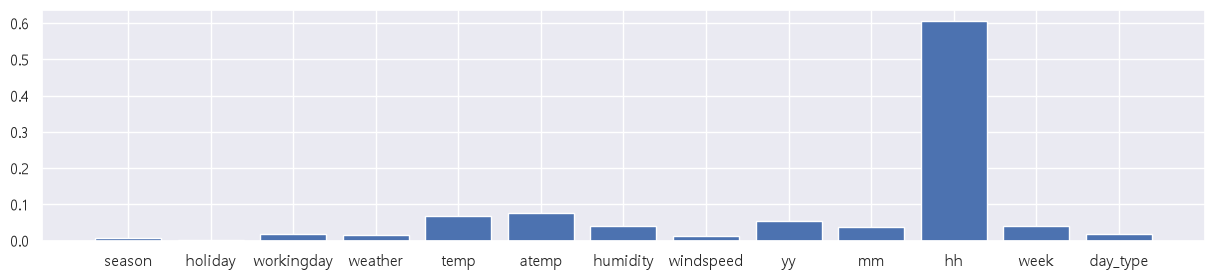

In [69]:
rf = myscore222(train)
imp = rf.feature_importances_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

* <b> 선형모델 : model.coef_ (회귀계수==기울기==가중치==중요도)

Ridge
rmsle : 1.2857
[ 3.22710188 -3.33323674 -1.63522323 -8.67888022 -1.86149919  8.0041822
 -1.44437771  0.54011295 85.66138738  5.50154094  6.47579107  1.54762632
 -1.69801351]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


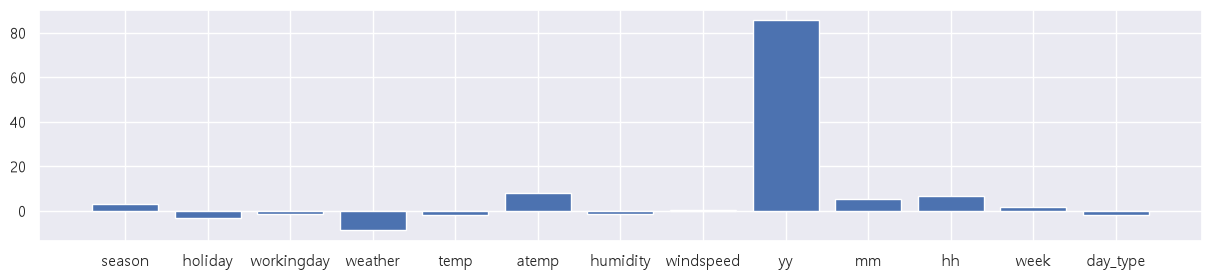

In [70]:
ridge = Ridge()
model = myscore222(train, ridge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))
plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

Lasso
rmsle : 1.2718
[ 0.         -0.         -0.         -5.62884455 -0.          6.32376964
 -1.49869547  0.38898873 79.16123026  6.05051491  6.42237285  1.33930431
 -0.        ]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


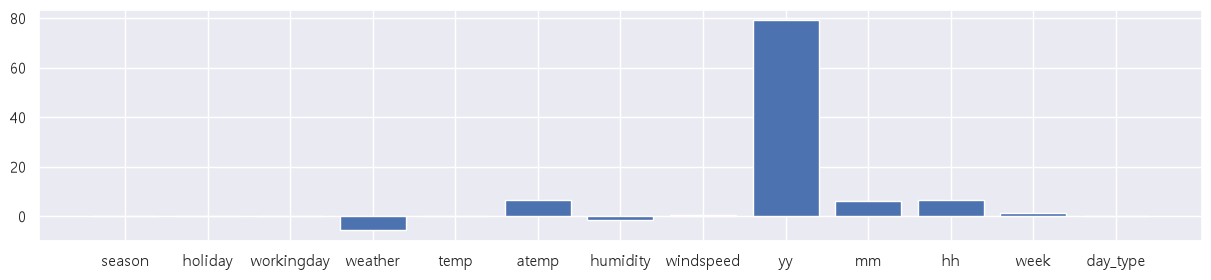

In [71]:
lasso = Lasso()
model = myscore222(train, lasso)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))
plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

<br> <font color=blue> **▼ 분석**
* Ridge/Lasso 모델은 선형모델 : 데이터에서 yy가 가장 수치가 크니 가장 중요하다고 보여줌 (X가 크면 y가 크다고 학습)
  * 다른 컬럼 > 100이하, yy만 2000이 넘어가서
* rmsle 점수도 낮음
* 트리모델 사용이 더 나을 수 있다

### 피쳐 수정 & 삭제

* 2011-11로, 2012-12로

In [72]:
train['yy'].value_counts()

yy
2012    5464
2011    5422
Name: count, dtype: int64

In [73]:
#train['yy'] = train['yy'].apply(lambda x: 1 if x == 2011 else 2)-----참고

train['yy'] = train['yy'].map({ 2011:1, 2012:2 })
test['yy'] = test['yy'].map({ 2011:1, 2012:2 })

Lasso
rmsle : 1.2718
[ 0.         -0.         -0.         -5.62884455 -0.          6.32376964
 -1.49869547  0.38898873 79.16123026  6.05051491  6.42237285  1.33930431
 -0.        ]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


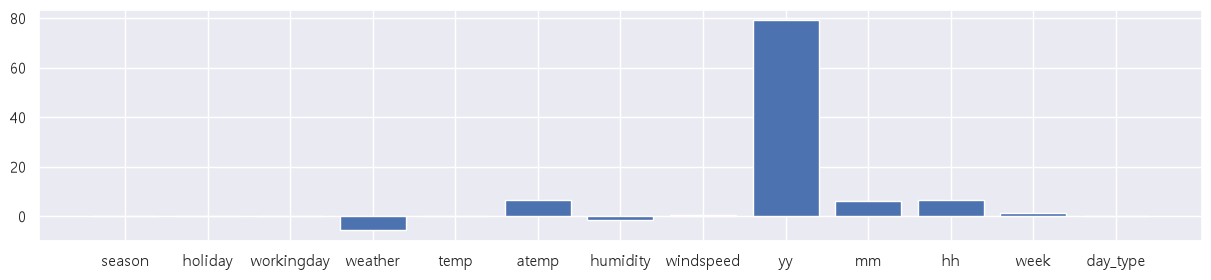

In [74]:
lasso = Lasso()
model = myscore222(train, lasso)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))
plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

* yy삭제

In [75]:
traincp = train.copy()
traincp = traincp.drop(columns=['yy'])
traincp.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,mm,hh,week,day_type,count,registered,casual
datetime,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,6.532701,1,0,5,1,16,13,3


In [76]:
traincp.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type', 'count',
       'registered', 'casual'],
      dtype='str')

Ridge
rmsle : 1.1372
[ 2.55231803  0.30578457  0.61088712 -7.12581382 -4.87989495 10.75461916
 -1.61201156  0.4927753   0.43553547  6.34203399  1.68510205 -0.30510255]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


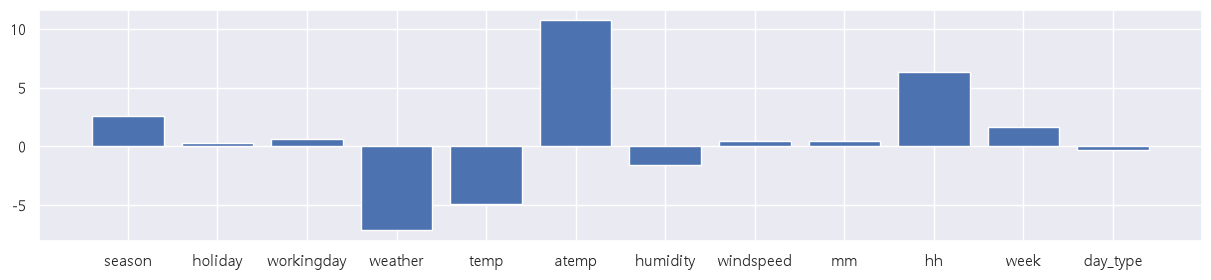

In [77]:
ridge = Ridge()
model = myscore222(traincp, ridge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))

col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp','humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']
plt.bar( col_list, imp, label="블루")
plt.tight_layout
plt.show()

### <font color=red> <b> => 우리 데이터에서 Lasso/Ridge 같은 선형모델은 적합하지 않다

## (3) 정규화_규제 : 모델교체

* <b> lec05 참조 (Boston House Price)
* 우리 데이터(트리모델)에는 적합하지 않음 (규제는 선형모델에서 효과적)

# **[5] 강력한 모델로 교체**
* 선형 보다는 트리모델이 좋은 성능을 보임
* pip install xgboost, lightgbm : *GradientBoosting

## **XGBoost**
* XGBoost(Extreme Gradient Boosting)는 정형(표 형태) 데이터 예측에서 뛰어난 성능과 빠른 속도를 보여주는 그레이디언트 부스팅(Gradient Boosting) 기반의 오픈소스 머신러닝 라이브러리
* https://xgboost.ai/about

XGBRegressor
rmsle : 0.5984


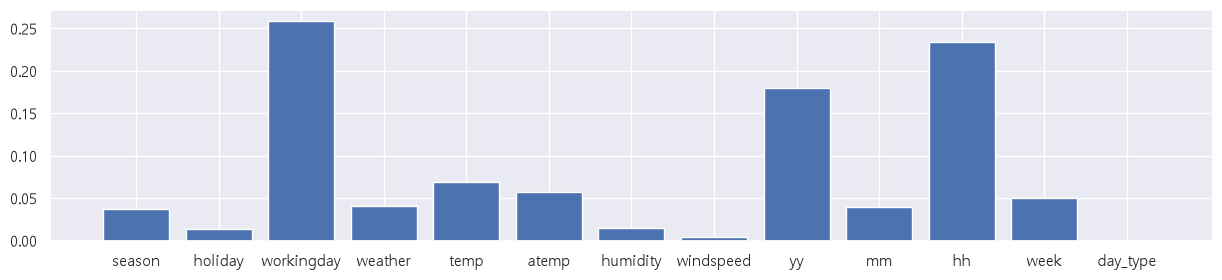

In [78]:
# import xgboost as xgb
# model = xgb.XGBRegressor()

from xgboost import XGBRegressor, XGBClassifier    #----Regressor 회귀 / Classifier 분류
xgb = XGBRegressor()


model = myscore222(train, xgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar( X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

XGBRegressor
rmsle : 0.6317


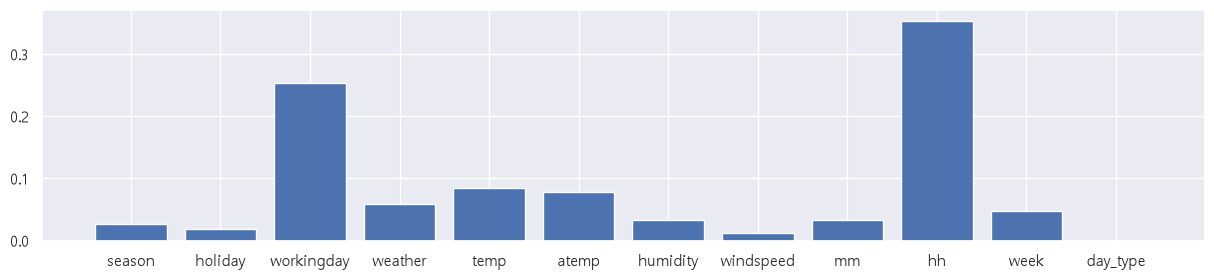

In [79]:
xgb = XGBRegressor()
model = myscore222(traincp, xgb)
imp = model.feature_importances_

# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp','humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']
plt.bar( col_list, imp, label="블루")
plt.tight_layout
plt.show()

## **LightGBM**
* LightGBM(Light Gradient Boosting Machine)은 마이크로소프트에서 개발한 빠르고 효율적인 트리 기반의 오픈소스 머신러닝 라이브러리

In [80]:
from lightgbm import LGBMRegressor, LGBMClassifier
model = LGBMRegressor()

LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 495
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 13
[LightGBM] [Info] Start training from score 159.125459
rmsle : 0.4284


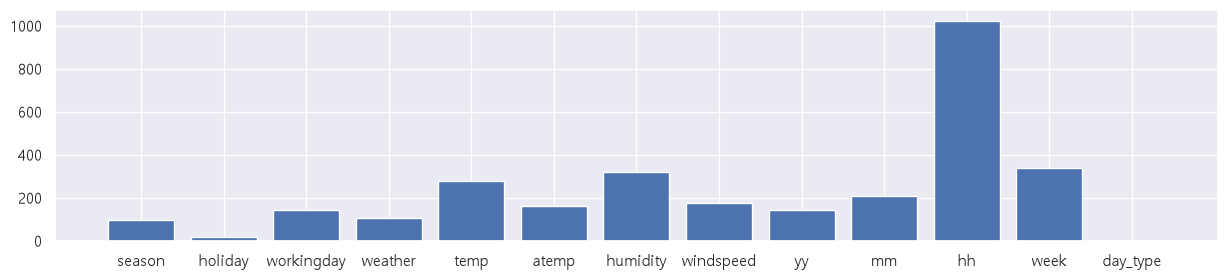

In [81]:
lgb = LGBMRegressor()

model = myscore222(train, lgb)
imp = model.feature_importances_

# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar( X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

## <font color=blue> **→3차 점수 : 풍속 채우기 + 모델 교체**
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등
* 3차_0.52408 : 1902등   ---- 오버피팅(과적합) : 해당 데이터만 과도하게 학습, 모르는 문제를 못 품 (데이터에 비해 무거운 모델 사용해서)

In [82]:
model = myscore222(train, lgb)

LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 495
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 13
[LightGBM] [Info] Start training from score 159.125459
rmsle : 0.4284


In [83]:
pred = model.predict(test)

pred = model.predict(test)
pred = np.maximum(pred, 0)

sub['count'] = pred
sub.head()
sub.to_csv("lec11_v03.csv", index=False)

In [84]:
lgb = LGBMRegressor()
model = myscore222(train, lgb)

pred = model.predict(test)
pred = np.maximum(pred, 0)

sub['count'] = pred
sub.head()
sub.to_csv("lec11_v04.csv", index=False)

LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 495
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 13
[LightGBM] [Info] Start training from score 159.125459
rmsle : 0.4284


# **[6] casual / registered 타겟 분리**
* 각각 예측한 후에 합산(=count)

In [85]:
train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type', 'count',
       'registered', 'casual'],
      dtype='str')

In [86]:
rf = RandomForestRegressor(
        n_estimators=100,
        random_state=1234)

model = myscore222(train, rf, MY_TARGET="casual")
pred_c = model.predict(test)
pred_c = np.maximum(pred_c, 0)

print(pred_c[:10])

RandomForestRegressor
rmsle : 0.5499
[1.56  0.87  1.005 0.405 0.38  0.23  2.03  3.26  8.35  6.69 ]


In [87]:
rf = RandomForestRegressor(
        n_estimators=100,
        random_state=1234)

model = myscore222(train, model=None, MY_TARGET="registered")
pred_r = model.predict(test)
pred_r = np.maximum(pred_r, 0)

print(pred_c[:10])

RandomForestRegressor
rmsle : 0.3528
[1.56  0.87  1.005 0.405 0.38  0.23  2.03  3.26  8.35  6.69 ]


In [88]:
0.5499 / (0.5499+0.3528)

0.609172482552343

## <font color=blue> **→4차 점수 : casual + registered**
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등
* 3차_0.52408 : 1902등
* 4차_0.43887 : 741등! 

In [89]:
count = pred_c + pred_r
print(count)

[ 12.29    6.22    4.145 ... 103.87  105.     51.59 ]


In [90]:
count = np.maximum(count, 0)
sub['count'] = count
sub.head()
sub.to_csv("lec11_v04.csv", index=False)

## <font color=blue> **→5차 점수 : casual(40%) + registered(60%)**
* 잘 맞추는 모델 기준 비율 분배
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등
* 3차_0.52408 : 1902등
* 4차_0.43887 : 741등!    ---- 22%
* 5차_0.65856 : 2409등

In [91]:
count = (pred_c * 0.4) + (pred_r * 0.6)
print(count)

[ 7.062  3.558  2.286 ... 61.45  62.28  30.362]


In [92]:
count = np.maximum(count, 0)
sub['count'] = count
sub.head()
sub.to_csv("lec11_v05.csv", index=False)